# Lab 02: Informed Search

## Overview of the lab
In this lab, we will learn to use external information in our favor in a way that can speed up the performance of our searches tremendously.

# Recap

## Search strategies Evaluation
Strategies are evaluated along the following dimensions:
  * **Completeness:** does it always find solution if one exists?
  * **Optimality**: does it always find a least-cost solution?
  * **Time complexity**: bumber of nodes generated/expanded. We are interested in the worst case scenario
  * **Space Complexity**: maximum number of nodes in memory

Time and space complexity are measured in terms of:
* **b** – maximum branching factor of the search tree
* **d** – depth of the least-cost solution
* **m** – maximum depth of the state space (may be ∞)

![image.png](images/state_space_tree.png)

In the following example, considaring thet *the initial state S is at level 0*:
* b = 3 (each node has a maximum of 3 children)
* m = 3 (maximum depth)
* d = 2 (the nearest goal state is at level 2)

## Global Search VS Local Search
* ***Global Search:*** Search strategies that look all over the state space. If necessary, all states will be traversed
* ***Local Search:*** They only look at the local area, so they can only look at states in this area. If the solution is outside of it, they will not be able to find it.

*Generally Local Search is not used for finding a path from state
A to state B. It is mostly used for optimization problems or problems where it is not mandatory to find the best solution*


### Uninformed Search:
 Uninformed strategies use only the information available in the problem definition.

### Informed Search:
 Informed strategies have information on the goal state which helps in more efficient searching. This information is obtained by a function (heuristic) that estimates how close a state is to the goal stat

# Heuristic
Heuristics in search problems are problem-specific estimation functions that guide a search algorithm toward promising states instead of exploring the entire search space blindly. Typically, a heuristic estimates how close a current state is to a goal state.

With heuristics, it becomes very easy to implement logic in our agent that enables them to “prefer” expanding states that are estimated to be closer to goal states when deciding which action to perform. 

A function $h(n)$ that estimates the cost (or distance) from a given state n to a goal state. It provides problem-specific guidance to search algorithms to prefer more promising states and reduce the search effort.

You can think of it as a function that nudges us to make certain decisions in the process of solving a problem instead of others.

### Examples
- **Pathfinding / Route Planning** - Straight-Line Distance(Euclidean distance)
- **8-Puzzle Problem** - Misplaced Tiles 
- **Choosing best move in chess** - Estimate board strength with a number

# Informed search 


- **Greedy** 
  - Greedy Search
  - Beam Search 
  - Hill Climbing
- **A*** 
  - Memory-Bounded A* 
  - iterative Deepening A* (IDA*)

In [12]:
from utils import Graph

edges = {
    "S":[('A',2),('B',3)],
    "A":[('C',4)],
    "B":[('D',2)],
    "C":[('G',4)],
    "D":[("H",3),("I",3),("E",2)],
    "E":[("J",2),("F",3)],
    "J":[("K",2)],
    "F":[("G",3)]
}
nodes = ["A","B","C","D","G","S"]
heuristic = {"S":8,"A":7,"B":5,"C":4,"G":0,"D":6,"H":9,"I":8,"E":6,"J":7,"F":3,"K":8}
graph = Graph(nodes,edges,heuristic=heuristic,start_node="S",end_node="G")

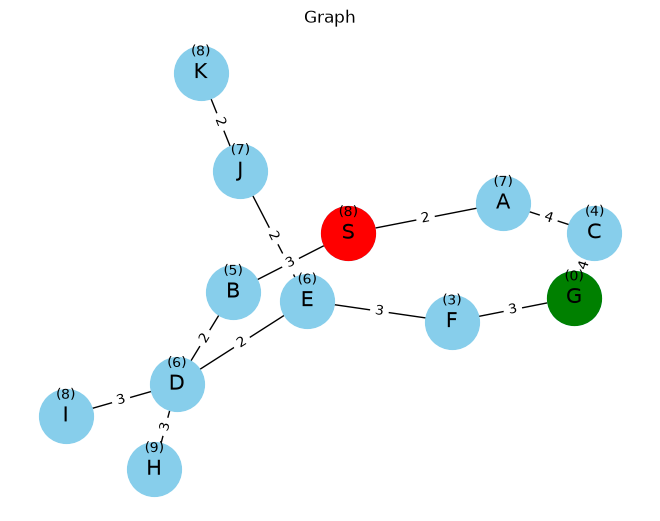

In [13]:
graph.show()

# Greedy

#### Idea
Use an evaluation function for each node as an estimate of “desirability”

#### Implementation
Greedy search expands the node that appears to be closest to goal, without considering the actual distance

In [14]:
from heapq import heappush,heappop

def greedy(edges,heuristic,start_node,end_node):

    queue = [(heuristic[start_node],start_node,[start_node])]
    visited = set()

    while queue:
        current_cost, current, path = heappop(queue)
        if current == end_node:
            print(current,end = " ")
            return current_cost,path 
        
        if current in visited:
            continue
        
        print(current,end = " ")
        visited.add(current)
        if current not in edges:
            continue

        for next,next_cost in edges[current]:
            if next not in visited:
                heappush(queue,(heuristic[next], next,path + [next]))

In [15]:
greedy(graph.edges,heuristic,graph.start_node,graph.end_node)

S B D E F G 

(0, ['S', 'B', 'D', 'E', 'F', 'G'])

| Algorithm | Complete | Optimal | Time Complexity | Space Complexity | Data structure|
 | ----- | ----- | ----- | ----- | ----- | ----- |
| Greedy | $No^*$ | $No$ | $O(b^m)$ | $O(b^m)$ | Priority Queue |

# Beam Search

#### Implementation
Beam Search is just gready search but with a queue with a limit $ l $

In [16]:

def beam_search(edges,heuristic,start_node,end_node,limit):

    queue = [(heuristic[start_node],start_node,[start_node])]
    visited = set()
    while queue:
        current_cost, current, path = queue.pop(0)
        if current == end_node:
            print(current,end = " ")
            return current_cost,path 

        if current in visited:
            continue

        visited.add(current)

        print(current,end = " ")

        if current not in edges:
            continue

        for next,next_cost in edges[current]:
            if next not in visited:
                queue.append((heuristic[next], next,path + [next]))
        
        queue.sort(key= lambda el: el[0])
        queue = queue[:limit]

In [17]:
beam_search(graph.edges,heuristic,graph.start_node,graph.end_node,2)

S B D E F G 

(0, ['S', 'B', 'D', 'E', 'F', 'G'])

| Algorithm | Complete | Optimal | Time Complexity | Space Complexity | Data structure|
 | ----- | ----- | ----- | ----- | ----- | ----- |
| Beam Search | $No$ |  $No$   | $O(bml)$ | $O(bl)$ | Limited Priority Queue |  


# Hill climbing

#### Implementation 
Beam Search but with queue limit 1.

In this case, it is better to remove the queue because it is actually not needed.

In [30]:
def hill_climbing(edges,heuristic,start_node,end_node):

    current = start_node
    path = [start_node]
    visited = set()
    best_value = heuristic[current]
    while True:
        if current == end_node:
            print(current,end = " ")
            return heuristic[current],path 

        print(current,end = " ")
        visited.add(current)

        if current not in edges:
            return "Dead end",path

        best_next = None
        best_value = float('inf')
        for next,next_cost in edges[current]:
            if next not in visited and heuristic[next] < best_value:
                best_value = heuristic[next]
                best_next = next

        if best_next is None:
            return "Dead end",path
        
        current = best_next
        path.append(current)
            

In [31]:
hill_climbing(graph.edges,heuristic,graph.start_node,graph.end_node)

S B D E F G 

(0, ['S', 'B', 'D', 'E', 'F', 'G'])

In [ ]:
beam_search(graph.edges,heuristic,graph.start_node,graph.end_node,1)

S B D E F G 

(0, ['S', 'B', 'D', 'E', 'F', 'G'])

| Algorithm | Complete | Optimal | Time Complexity | Space Complexity | Data structure|
 | ----- | ----- | ----- | ----- | ----- | ----- |
| Hill Climbing | $No$ | $No$ | $O(bm)$ | $O(b)$ | "Limited Priority Queue"  |


## How These Algorithms Are Used

The algorithms discussed above are not typically used as standard graph search algorithms. Instead, they are more commonly used for optimization. To use them effectively, we first need to define an appropriate heuristic (cost function) to optimize. We can then run `hill_climbing` or a similar algorithm from a random or predefined starting point to find a new state with a better overall heuristic value, often with relatively little computational effort.

These algorithms do not guarantee that we will find the globally optimal state for the chosen heuristic. However, in many cases, finding the absolute best solution is not necessary, as long as we can find a solution that is good enough.

#### Example

**An example** of how hill climbing can be applied is in a Rubik's Cube solver.

The state space of a Rubik's Cube is enormous, making it impractical for standard BFS or DFS algorithms to search for a solution efficiently.

A better approach is to define an appropriate heuristic (cost function) that estimates how far the current state is from the solved state. For example, the heuristic could count the number of cubies that are not in their correct positions.

We can then generate all possible move sequences up to a predefined depth $l$ and select the resulting state with the best heuristic value. By repeating this process, we can gradually move toward a solution using a relatively small number of operations. However, this approach does not guarantee that a solution will be found, as hill climbing can get stuck in a local optimum. With a few optimization, this algorithm can get 100% success rate.


# Heuristics
$h(n)$ - heuristic

***admissible heuristic*** - $h(n) ≤ h^*(n)$ where $h^*(n)$ is the true cost from n. (Also require $h(n) ≥ 0$ , so $h(G) = 0$ for any goal $G$.). A heuristic $h(n)$ is admissible if it never overestimates the true cost of reaching the goal state $G$ from any node $n$.

**consistent heuristic** - $h(n) ≤ c(n, a, n') + h(n')$ for any $ n,n' $

![image.png](images/consistent_heuristic.png)

If $h(n)$ is consistent, then it is also admissible; however, the converse is not necessarily true.

#### Dominance
**Dominance** - If $h_2(n) ≥ h_1(n)$ for all $n$ (both admissible) then $h_2$ dominates $h_1$ and is better for search

Typical search costs:
- $d = 14$ IDS $= 3,473,941$ $nodes$
  - $A^*(h_1) = 539$ $nodes$
  - $A^*(h_2) = 113$ $nodes$
- $d = 24$ IDS $≈ 54,000,000,000$ $nodes$
    - $A^*(h_1) = 39,135$ $nodes$
    - $A^*(h_2) = 1,641$ $nodes$



# A*

**Idea:** avoid expanding paths that are already expensive 
* Evaluation function $f(n) = g(n) + h(n)$
   * $g(n)$ = cost so far to reach n
   * $h(n)$ = estimated cost from n to goal 
   * $f(n)$ = estimated total cost of path trough **n** to goal


In [ ]:
from heapq import heappush,heappop

def a_star(edges,heuristic,start_node,end_node):
    queue = [(heuristic[start_node],0,start_node,[start_node])]
    optimal_costs = {start_node:0}
    while queue:
        heuristic_cost,current_cost ,current,path = heappop(queue)
        if current == end_node:
            print(current,end = " ")
            return current_cost,path 

        if optimal_costs[current]< current_cost:
            continue

        print(current,end = " ")

        if current not in edges:
            continue

        for next,next_cost in edges[current]:

            next_heuristic_cost = current_cost + next_cost + heuristic[next]
            if next in optimal_costs and optimal_costs[next]<=current_cost + next_cost:
                continue

            optimal_costs[next]=current_cost + next_cost
            heappush(queue,(next_heuristic_cost, current_cost + next_cost,next,path + [next]))

In [ ]:
a_star(graph.edges,heuristic,graph.start_node,graph.end_node)

S B A C G 

(10, ['S', 'A', 'C', 'G'])

| Algorithm | Complete | Optimal | Time Complexity | Space Complexity | Data structure|
 | ----- | ----- | ----- | ----- | ----- | ----- |
| A* | $Yes^*$  | $Yes$ | $O(b^d)$ | $O(b^d)$ | Priority Queue  |


## Optimality of A*

**Theorem:** If $h(n)$ is admissible, A* using **tree search** is optimal

**Theorem:** If $h(n)$ is consistent, A* using **graph search** is optimal

A* is often used for the common pathfinding problem in applications such as video games, but was originally designed as a general graph traversal algorithm. It finds applications in diverse problems, including the problem of parsing using stochastic grammars in NLP. Other cases include an Informational search with online learning.

# Iterative Deepening A*

Iterative Deepening A is combination between A* and iterative-deepening-search, i.e., uses A* evaluation function as a threshold and runs DLS

[Pseudo Code](https://en.wikipedia.org/wiki/Iterative_deepening_A*#Pseudocode)

## 9. Summary

| Algorithm | Complete | Optimal | Time Complexity | Space Complexity | Data structure|
 | ----- | ----- | ----- | ----- | ----- | ----- |
| Greedy | $No^*$ | $No$ | $O(b^m)$ | $O(b^m)$ | Priority Queue |
| Beam Search | $No$ |  $No$   | $O(bml)$ | $O(bl)$ | Limited Priority Queue |  
| Hill Climbing | $No$ | $No$ | $O(bm)$ | $O(b)$ | "Limited Priority Queue"  |
| A* | $Yes^*$  | $Yes$ | $O(b^d)$ | $O(b^d)$ | Priority Queue  |
| IDA* | $Yes$ | $Yes$ | $O(b^d)$ | $O(bd)$ | Stack  |


# Homework

The [game](https://appzaza.com/tile-slide-game) starts with a square board consisting of numbered tiles from **1** to **N** and one empty tile, represented by **0**. The goal is to arrange the tiles in numerical order. A move consists of sliding a tile from above, below, to the left, or to the right of the empty tile into the empty position.

The input consists of an integer **N** - the number of numbered tiles (**8**, **15**, **24**, etc.), an integer **I** - the index of the empty tile (**0**) in the goal state (if **I = -1**, the default index is used, corresponding to the bottom-right corner), followed by the initial board configuration.

Using the **IDA*** algorithm and the **Manhattan distance** heuristic, output the following:

1. The first line must contain the **length of the optimal path** from the initial state to the goal state.
2. Each subsequent line must contain one of the **moves** (*left*, *right*, *up*, or *down*) that leads to the solution.

**Notes:**

* Not every initial puzzle configuration is solvable. Solvability can be checked using the methods described in this [link](https://www.cs.princeton.edu/courses/archive/spring18/cos226/assignments/8puzzle/index.html). **Note** that for even-sized boards where the empty tile (**0**) is at index **0** in the goal state, the standard solvability-checking rule must be modified. **If the puzzle is unsolvable, the output must be -1.**
* Include an option to measure and print the time required to find a solution. More details are available in the *Automatic Testing* section.
* The attached files contain **sample input/output configurations and test puzzles** to help you develop your solution. However, **they do not cover all the test cases** that will be used during evaluation.
* An implementation using **A*** instead of **IDA*** will be accepted, but the grade will be reduced.

**Sample Input:**

```text
8
-1
1 2 3
4 5 6
0 7 8
```

**Sample Output:**

```text
2
left
left
```
![image.png](images/SlidingBlocksNPuzzle.png)


## Manhattan Distance
Manhattan Distance between two point $x(x_1,x_2)$ and $y(y_1,y_2)$ is equal to:

$ManhattanDistance(x,y)=|x_1 - y_1|+|x_2 - y_2|$

![image.png](images/ManhattanDistance.png)
